# **Simple Linear Regression**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day48-simple-linear-regression/placement.csv")
df.sample(5)

,cgpa,package
155,6.98,3.09
198,7.63,3.96
105,6.66,2.82
50,9.58,4.43
68,7.56,2.99


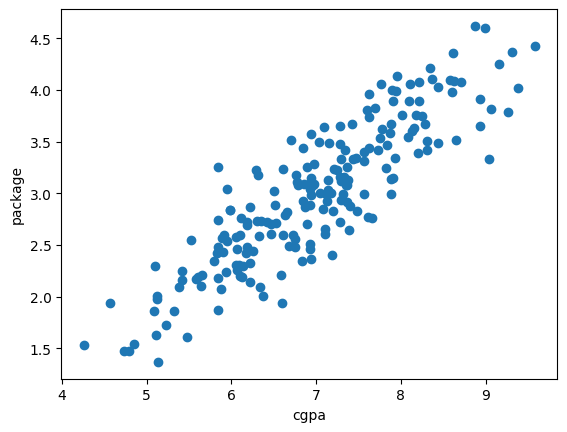

In [3]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("cgpa")
plt.ylabel('package')
plt.show()

In [4]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1].values

In [5]:
y

array([3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6 , 2.48, 2.31, 3.51, 1.86,
       2.6 , 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.83, 3.16, 2.93,
       2.3 , 2.48, 2.71, 3.65, 3.42, 2.16, 2.24, 3.49, 3.26, 3.89, 3.08,
       2.73, 3.42, 2.87, 2.84, 2.43, 4.36, 3.33, 4.02, 2.7 , 2.54, 2.76,
       1.86, 3.58, 2.26, 3.26, 4.09, 4.62, 4.43, 3.79, 4.11, 2.61, 3.09,
       3.39, 2.74, 1.94, 3.09, 3.31, 2.19, 1.61, 2.09, 4.25, 2.92, 3.81,
       1.63, 2.89, 2.99, 2.94, 2.35, 3.34, 3.62, 4.03, 3.44, 3.28, 3.15,
       4.6 , 2.21, 3.  , 3.44, 2.2 , 2.17, 3.49, 1.53, 1.48, 2.77, 3.55,
       1.48, 2.72, 2.66, 2.14, 4.  , 3.08, 2.42, 2.79, 2.61, 2.84, 3.83,
       3.24, 4.14, 3.52, 1.37, 3.  , 3.74, 2.82, 2.19, 2.59, 3.54, 4.06,
       3.76, 2.25, 4.1 , 2.37, 1.87, 4.21, 3.33, 2.99, 2.88, 2.65, 1.73,
       3.02, 2.01, 2.3 , 2.31, 3.16, 2.6 , 3.11, 3.34, 3.12, 2.49, 2.01,
       2.48, 2.58, 2.83, 2.6 , 2.1 , 3.13, 3.89, 2.4 , 3.15, 3.18, 3.04,
       1.54, 2.42, 2.18, 2.46, 2.21, 3.4 , 3.67, 2.

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [8]:
class LinearRegression:

  def __init__(self):
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num,den=0,0
    for i in range(X_train.shape[0]):
      num=num+((X_train[i]-X_train.mean())*(y_train[i]-y_train.mean()))
      den=den+((X_train[i]-X_train.mean())*(X_train[i]-X_train.mean()))

    self.m=num/den

    self.b=y_train.mean()-(self.m*X_train.mean())

  def predict(self,X_test):
    return self.m*X_test+self.b

  def show(self):
    print("The Coefficient Value is : ",self.m)
    print("The Intercept Value is : ", self.b)

In [9]:
lr=LinearRegression()

In [10]:
lr.fit(X_train,y_train)

In [11]:
lr.show()

The Coefficient Value is :  [0.55795197]
The Intercept Value is :  [-0.89611192]


In [12]:
y_pred=lr.predict(X_test)
lr.predict(X_test[0].reshape(1,1))

array([[3.89111601]])

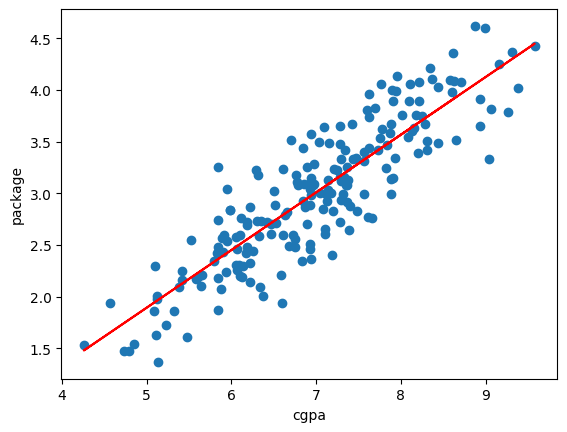

In [13]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel("cgpa")
plt.ylabel('package')
plt.show()

# **Multiple Linear Regression**

In [14]:
from sklearn.datasets import load_diabetes

In [15]:
X,y=load_diabetes(return_X_y=True)

In [16]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [17]:
import plotly.express as px

fig = px.scatter_matrix(
    df,
    dimensions=df.columns[:-1],   # all features except target
    color="target",
    title="Scatter Matrix of Diabetes Dataset"
)

fig.show()

In [18]:
X = df.drop("target", axis=1).values
y = df["target"].values

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
class MultipleLinearRegression:

  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)
    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred

  def show(self):
    print("The Coefficient Value is : ",self.coef_)
    print("The Intercept Value is : ", self.intercept_)

In [21]:
mlr = MultipleLinearRegression()

In [22]:
mlr.fit(X_train,y_train)

In [23]:
mlr.show()

The Coefficient Value is :  [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
The Intercept Value is :  151.88331005254165


In [24]:
mlr.predict(X_test[0])

np.float64(154.12138809538368)

# **Polynomial Linear Regression**

In [25]:
np.random.seed(42)

n_samples = 200

# 3 input features
x1 = np.random.uniform(-5, 5, n_samples)
x2 = np.random.uniform(-3, 3, n_samples)
x3 = np.random.uniform(0, 10, n_samples)

# target with a real polynomial relationship (matches your class - per-feature, no interactions)
y = (5
     + 2*x1 - 1.5*x1**2
     + 3*x2 + 0.8*x2**2
     - 1*x3 + 0.3*x3**2
     + np.random.normal(0, 2, n_samples))  # noise

df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'y': y})
df.head()

,x1,x2,x3,y
0,-1.254599,0.852190,1.031239,1.494609
1,4.507143,-2.495160,9.025529,-5.135265
2,2.319939,-2.030228,5.052524,1.165291
3,0.986585,2.391325,8.264575,27.417768
4,-3.439814,0.638574,3.200496,-18.621001


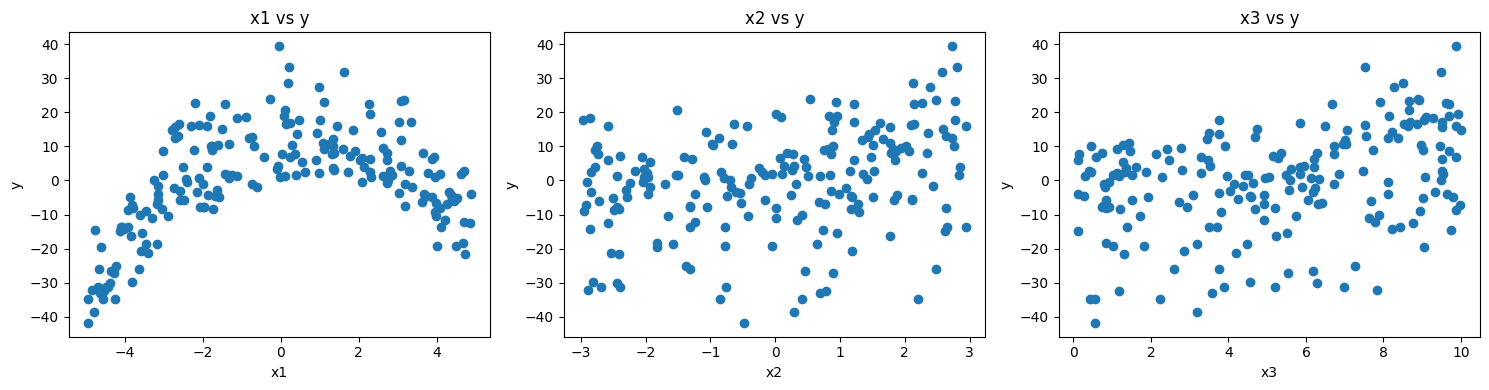

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# x1 vs y
axes[0].scatter(df['x1'], df['y'])
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')
axes[0].set_title('x1 vs y')

# x2 vs y
axes[1].scatter(df['x2'], df['y'])
axes[1].set_xlabel('x2')
axes[1].set_ylabel('y')
axes[1].set_title('x2 vs y')

# x3 vs y
axes[2].scatter(df['x3'], df['y'])
axes[2].set_xlabel('x3')
axes[2].set_ylabel('y')
axes[2].set_title('x3 vs y')

plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X = df[['x1', 'x2', 'x3']].values
y = df['y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coef_ = None
        self.intercept_ = None

    def _transform(self, X):
        # convert X into [X, X^2, X^3, ..., X^degree]
        X = np.array(X)
        X_poly = X.reshape(-1, 1) if X.ndim == 1 else X
        X_new = X_poly.copy()
        for d in range(2, self.degree + 1):
            X_new = np.hstack((X_new, X_poly ** d))
        return X_new

    def fit(self, X_train, y_train):
        X_poly = self._transform(X_train)
        X_poly = np.insert(X_poly, 0, 1, axis=1)  # add bias column
        betas = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self, X_test):
        X_poly = self._transform(X_test)
        return np.dot(X_poly, self.coef_) + self.intercept_

    def show(self):
        print("The Coefficient Value is : ", self.coef_)
        print("The Intercept Value is : ", self.intercept_)

In [29]:
plr = PolynomialRegression()

In [30]:
plr.fit(X_train,y_train)

In [31]:
plr.show()

The Coefficient Value is :  [ 1.95718566  2.90882691 -1.21212824 -1.52875434  0.70856458  0.32920865]
The Intercept Value is :  5.457778496386997


In [32]:
y_pred = plr.predict(X_test)

In [33]:
y_pred[0]

np.float64(5.558637829744869)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



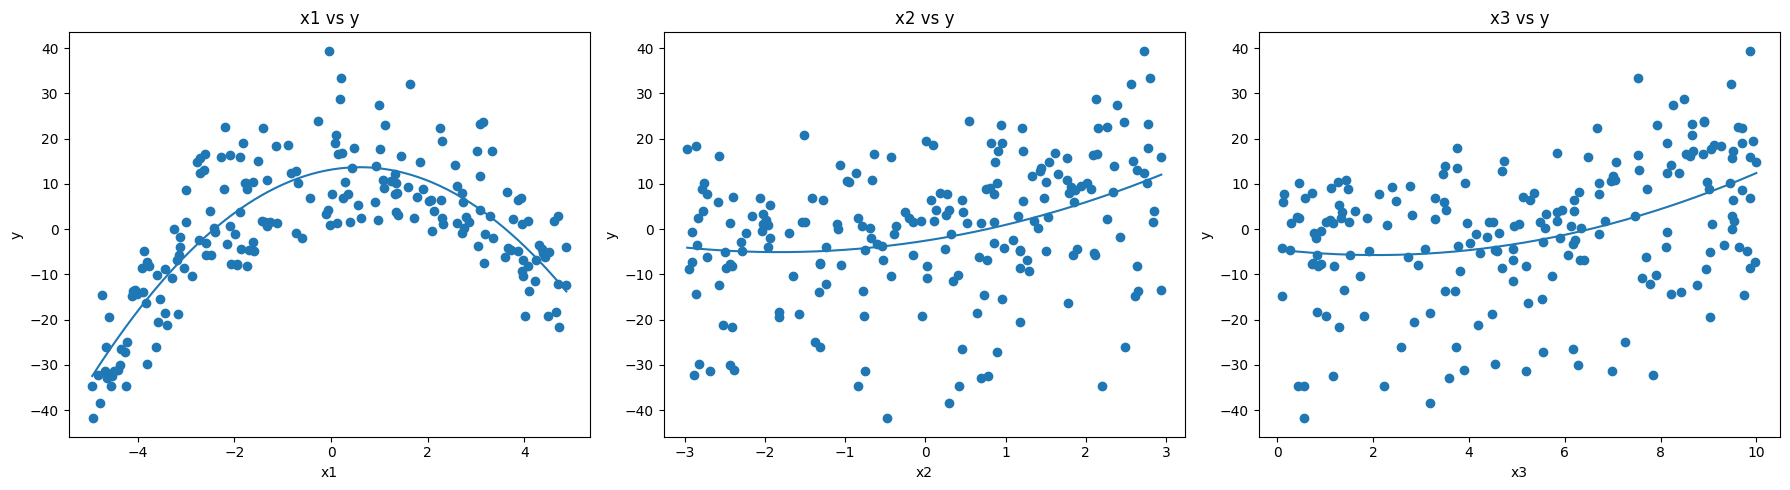

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

features = ['x1', 'x2', 'x3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):

    # Take one feature
    X = df[[feature]]
    y = df['y']

    # Create polynomial features
    poly = PolynomialFeatures(degree=2)

    # Transform the feature into [1, x, x²]
    X_poly = poly.fit_transform(X)

    # Train Polynomial Regression model
    lr = LinearRegression()
    lr.fit(X_poly, y)

    # Create smooth values for plotting the fitted curve
    X_range = np.linspace(
        X[feature].min(),
        X[feature].max(),
        200
    ).reshape(-1, 1)

    # Predict values using the trained model
    y_pred = lr.predict(poly.transform(X_range))

    # Plot actual data points
    axes[i].scatter(X, y)

    # Plot fitted polynomial curve
    axes[i].plot(X_range, y_pred)

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('y')
    axes[i].set_title(f'{feature} vs y')

plt.tight_layout()
plt.show()